In [43]:
import numpy as np
import pandas as pd

# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [29]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [32]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])


print(A @ e_1)
print(A@e_2)
print(A@e_3)

[1 4 7]
[2 5 8]
[3 6 9]


Each array has a different column that it will multiplly by, e1 being the first column, e2 being the second, and e3 being the third. As explained earlier it's "matrix row times columnn vector" 

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [33]:
u = np.ones(3)
print(A@u)

[ 6. 15. 24.]


The new vector generated is the addition of the columns in a times the vector u. since u is a vector of 1's 
then the resulting vector is just going to the the addition of the values in each column of a

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [34]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])
print(x@A)

[-2  4 11]


It always return the original vector given to it. in this case it returns only the first value, and then only the second, and then only the third. 
So you can see how it returns the same vector that it's given

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [35]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])
print(A@x)

[11 -2  4]


This time it changes the order, by using 1s and 0s you cna pick and choose what value of the vector you want to keep

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [39]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [40]:
print(A@e_1)
print(A@e_2)
print(A@e_3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


Each one of these vectors when multiplied by our array returns a different column as a vector

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [41]:
vectors = [e_1, e_2, e_3]
names = ['e_1', 'e_2', 'e_3']
for name, v in zip(names, vectors):
    result = v.copy()  # start with the vector
    print(f"Starting with {name}: {result}")
    for i in range(5):
        result = A @ result
        print(f"After multiplication {i+1}: {result}")
    print("-" * 30)

Starting with e_1: [1 0 0]
After multiplication 1: [0.50052958 0.02574731 0.47372311]
After multiplication 2: [0.34368862 0.20257047 0.45374091]
After multiplication 3: [0.30404142 0.26036337 0.43559521]
After multiplication 4: [0.29476439 0.27514859 0.43008701]
After multiplication 5: [0.29266551 0.27862515 0.42870935]
------------------------------
Starting with e_2: [0 1 0]
After multiplication 1: [0.24049286 0.39251588 0.36699127]
After multiplication 2: [0.28214379 0.29937825 0.41847795]
After multiplication 3: [0.29004438 0.28341002 0.42654561]
After multiplication 4: [0.29163968 0.2804039  0.42795643]
After multiplication 5: [0.29197422 0.27979983 0.42822595]
------------------------------
Starting with e_3: [0 0 1]
After multiplication 1: [0.18358131 0.37907577 0.43734292]
After multiplication 2: [0.26334088 0.31930609 0.41735304]
After multiplication 3: [0.28521895 0.29032145 0.4244596 ]
After multiplication 4: [0.29050361 0.28220175 0.42729464]
After multiplication 5: [0.2917

The end result for all three seems really similar, at the beginning they are quite different bu the last multiplication they are all pretty close to 
.29,.27/.28, and then .428

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [4]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [2]:
init_condition = np.array([1,0])
print(init_condition)

[1 0]


In [5]:
p_1=T @ init_condition
print(p_1)

[0.25 0.75]


In [7]:
p_2 = T @ p_1
print(p_2)

[0.4375 0.5625]


In [8]:
p_3 = T @ p_2

In [9]:
n = 100
p = np.array([1,0])
for t in range(n):
    print(p)
    p = T @ p

[1 0]
[0.25 0.75]
[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]
[0.40000004 0.59999996]
[0.39999999 0.60000001]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0

In [10]:
n = 100
p = np.array([0,1])
for t in range(n):
    print(p)
    p = T @ p

[0 1]
[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]
[0.39990234 0.60009766]
[0.40002441 0.59997559]
[0.3999939 0.6000061]
[0.40000153 0.59999847]
[0.39999962 0.60000038]
[0.4000001 0.5999999]
[0.39999998 0.60000002]
[0.40000001 0.59999999]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6

In [25]:
n = 10000
state = 0
sim = []
for t in range(n):
    sim.append(state)
    prob = T[:, state]
    state = np.random.choice(a=[0,1], p=prob)

print(sim)

[0, np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64

In [27]:
x = np.array(sim)
np.mean(x)

np.float64(0.5973)

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [44]:
weatherdf = pd.read_csv('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/assignments_branch/understanding_uncertainty_assignments/cville_weather.csv')

In [47]:
weatherdf['rain']=np.where(weatherdf['PRCP']>0,1,0)
weatherdf.head(3).T

,0,1,2
STATION,US1VACRC002,US1VACRC002,US1VACRC002
NAME,"CHARLOTTESVILLE 0.5 NNE, VA US","CHARLOTTESVILLE 0.5 NNE, VA US","CHARLOTTESVILLE 0.5 NNE, VA US"
DATE,2024-01-04,2024-01-07,2024-01-09
DAPR,NaN,NaN,NaN
DAPR_ATTRIBUTES,NaN,NaN,NaN
MDPR,NaN,NaN,NaN
MDPR_ATTRIBUTES,NaN,NaN,NaN
PRCP,0.03,1.08,0.24
PRCP_ATTRIBUTES,",,N",",,N",",,N"
SNOW,NaN,NaN,NaN


In [48]:
rain_series = weatherdf['rain'].values
n00 = np.sum((rain_series[:-1] == 0) & (rain_series[1:] == 0))
n01 = np.sum((rain_series[:-1] == 0) & (rain_series[1:] == 1))
n10 = np.sum((rain_series[:-1] == 1) & (rain_series[1:] == 0))
n11 = np.sum((rain_series[:-1] == 1) & (rain_series[1:] == 1))

# Transition matrix: rows = next day, columns = today
T = np.array([[n00/(n00+n01), n01/(n00+n01)],
              [n10/(n10+n11), n11/(n10+n11)]])

In [49]:
p_rain_if_clear = T[1,0]
p_rain_if_rain = T[1,1]

print(f"Probability of rain if yesterday was clear: {p_rain_if_clear:.2f}")
print(f"Probability of rain if yesterday was rainy: {p_rain_if_rain:.2f}")

Probability of rain if yesterday was clear: 0.35
Probability of rain if yesterday was rainy: 0.65


In [50]:
p = np.array([1,0])  # start clear
n_steps = 20
for t in range(n_steps):
    p = T @ p
    print(f"Step {t+1}: {p}")

# Repeat starting from rainy day
p = np.array([0,1])
for t in range(n_steps):
    p = T @ p
    print(f"Step {t+1}: {p}")

Step 1: [0.73160173 0.35195531]
Step 2: [0.62970529 0.48557388]
Step 3: [0.59102067 0.5363017 ]
Step 4: [0.57633419 0.55556033]
Step 5: [0.57075852 0.5628718 ]
Step 6: [0.56864174 0.56564757]
Step 7: [0.56783811 0.56670139]
Step 8: [0.56753302 0.56710146]
Step 9: [0.56741719 0.56725335]
Step 10: [0.56737321 0.56731101]
Step 11: [0.56735652 0.5673329 ]
Step 12: [0.56735018 0.56734122]
Step 13: [0.56734777 0.56734437]
Step 14: [0.56734686 0.56734557]
Step 15: [0.56734651 0.56734602]
Step 16: [0.56734638 0.5673462 ]
Step 17: [0.56734633 0.56734626]
Step 18: [0.56734631 0.56734629]
Step 19: [0.56734631 0.5673463 ]
Step 20: [0.5673463 0.5673463]
Step 1: [0.26839827 0.64804469]
Step 2: [0.37029471 0.51442612]
Step 3: [0.40897933 0.4636983 ]
Step 4: [0.42366581 0.44443967]
Step 5: [0.42924148 0.4371282 ]
Step 6: [0.43135826 0.43435243]
Step 7: [0.43216189 0.43329861]
Step 8: [0.43246698 0.43289854]
Step 9: [0.43258281 0.43274665]
Step 10: [0.43262679 0.43268899]
Step 11: [0.43264348 0.4326671

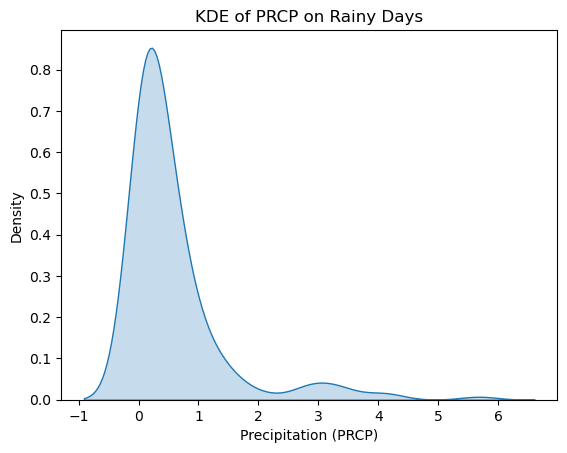

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select rainy days
rainy_days = weatherdf[weatherdf['rain']==1]['PRCP']

# Plot KDE
sns.kdeplot(rainy_days, fill=True)
plt.xlabel('Precipitation (PRCP)')
plt.title('KDE of PRCP on Rainy Days')
plt.show()

I think the best way to improve it is to include the season, certain seasons are more likly to have rain.
I also think including the amount of rain instead of just rain or no rain would be helpful, 
it'd be more likly to be rainy the day after a big storm I would think then a day where it just drizzles.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [61]:
taxi_data = pd.read_pickle('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/assignments_branch/data/taxicab.pkl')

In [62]:
taxi_data

[0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
 0     Outside Manhattan
             ...        
 29                 SoHo
 29                 SoHo
 13    Greenwich Village
 3               Chelsea
 3               Chelsea
 Name: nbhd, Length: 26026, dtype: object,
 22              Midtown
 17             Kips Bay
 17             Kips Bay
 7          East Village
 7          East Village
             ...        
 34      Upper East Side
 34      Upper East Side
 34      Upper East Side
 34      Upper East Side
 0     Outside Manhattan
 Name: nbhd, Length: 30184, dtype: object,
 3               Chelsea
 34      Upper East Side
 34      Upper East Side
 0     Outside Manhattan
 0     Outside Manhattan
             ...        
 20      Lower East Side
 20      Lower East Side
 34      Upper East Side
 34      Upper East Side
 7          East Village
 Name: nbhd, Length: 21202, dtype: object,
 13    Greenwich Village
 6           East Har

In [63]:
all_states = pd.concat(taxi_data)
states = sorted(all_states.unique())

In [64]:
state_to_idx = {s: i for i, s in enumerate(states)}
idx_to_state = {i: s for s, i in state_to_idx.items()}

In [66]:
cleaned_trajs = [t.dropna().reset_index(drop=True) for t in taxi_data]

In [67]:
n_states = len(states)
T = np.zeros((n_states, n_states))

for traj in cleaned_trajs:
    for a, b in zip(traj[:-1], traj[1:]):
        i, j = state_to_idx[a], state_to_idx[b]
        T[i, j] += 1

# Normalize rows to sum to 1 (probabilities)
T = (T.T / T.sum(axis=1)).T
T = np.nan_to_num(T)  # handle rows that sum to 0

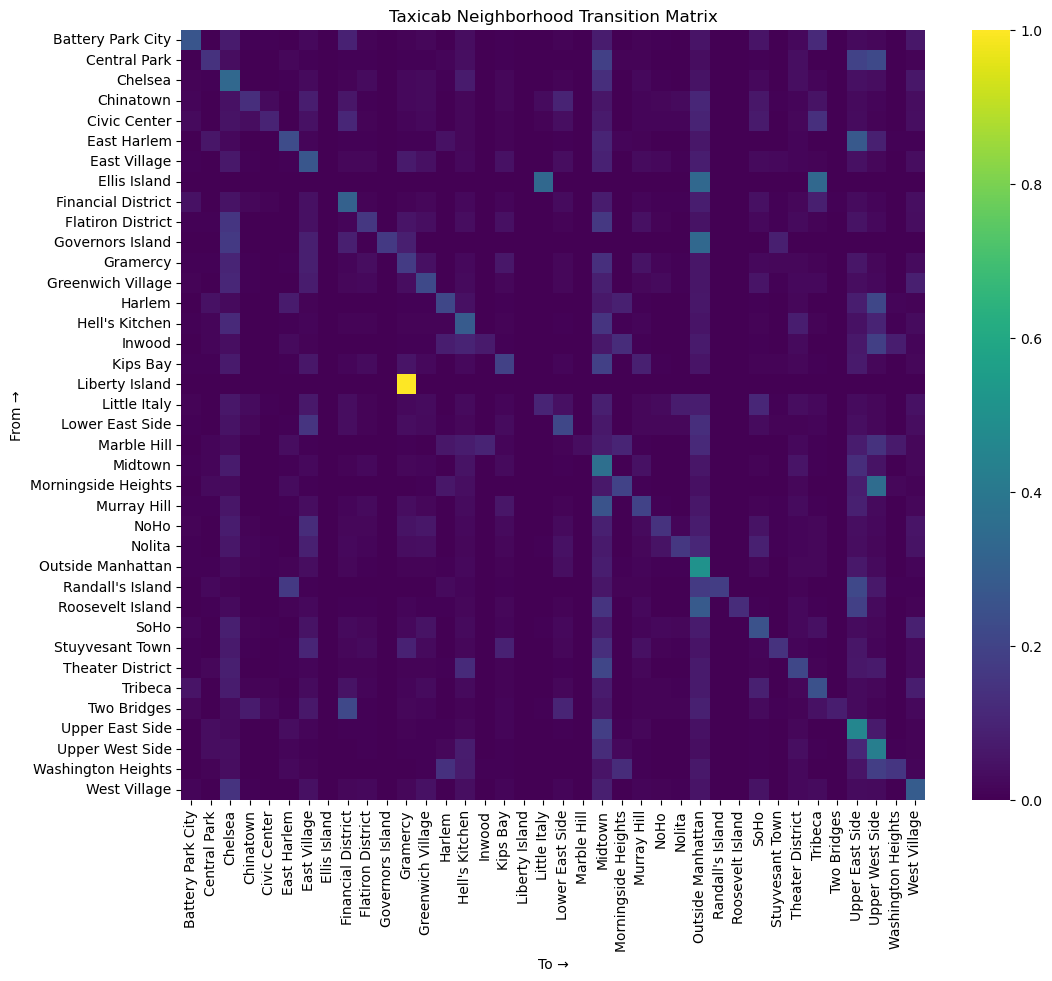

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(T, xticklabels=states, yticklabels=states, cmap="viridis")
plt.title("Taxicab Neighborhood Transition Matrix")
plt.xlabel("To →")
plt.ylabel("From →")
plt.show()

Cabs are most likely order 1, and not 2 or more. Because the next stop depends mostly on where the customer is picked up and not on where the taxi was on the stops before. Since it's usually a new customer, the previous customers shouldn't impact the chain.

In [72]:
def print_forecast(title, forecast_probs, n=5):
    print(f"\n{title}")
    print("-" * len(title))
    for state, p in top_states(forecast_probs, n):
        print(f"{state:<20} {p:.3f}")

print_forecast("2 Trips Ahead", forecast_2)
print_forecast("3 Trips Ahead", forecast_3)
print_forecast("5 Trips Ahead", forecast_5)
print_forecast("10 Trips Ahead", forecast_10)


2 Trips Ahead
-------------
Midtown              0.173
Hell's Kitchen       0.119
Chelsea              0.109
Upper West Side      0.099
Upper East Side      0.087

3 Trips Ahead
-------------
Midtown              0.173
Upper East Side      0.108
Chelsea              0.097
Upper West Side      0.092
Outside Manhattan    0.090

5 Trips Ahead
-------------
Midtown              0.169
Upper East Side      0.120
Outside Manhattan    0.099
Chelsea              0.088
Upper West Side      0.083

10 Trips Ahead
--------------
Midtown              0.168
Upper East Side      0.122
Outside Manhattan    0.103
Chelsea              0.086
Upper West Side      0.079


The chain was told to start in Hell's Kitchen and then model 2 trips-10 trips. What this shows is that Midtown even when in Hell's Kitchen is the most likley destination. However, something to note is that originall Hell's Kitchen was the second most likely destination. But after 3 trips it is no longer a top 5 destination. What this suggests to me is that for the most part Hell's Kitchen is not a top destination, and that beyond Mitwon being the top location it doesn't seem like any other destinations are overwhelmingly popular.

In [70]:
pi = start.copy()
for _ in range(100):
    new_pi = pi @ T
    if np.allclose(new_pi, pi, atol=1e-6):
        break
    pi = new_pi

steady_state = pi / pi.sum()
top_states(steady_state)

[('Midtown', np.float64(0.1677498509297471)),
 ('Upper East Side', np.float64(0.12184273787782324)),
 ('Outside Manhattan', np.float64(0.1029489093306323)),
 ('Chelsea', np.float64(0.08615140426512756)),
 ('Upper West Side', np.float64(0.07854502075289495))]

Midtown is by far the most popular location, with around 1/6th of routes going there

Code was written with the assistance of ChatGPT, but I feel like I understand how the code works and the idea of the markov chain that this asisgnment is focused on